<a href="https://colab.research.google.com/github/davis-mironga/marsabit-ecosystem-analysis/blob/main/03_Spatial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Notebook 3 — Spatial Analysis
## The Marsabit Footprint: Moran's I, LISA Hotspots, Distance-Decay & LCI (1990–2024)

---

**Purpose of this Notebook:**
Using the NDVI change maps and LULC classifications from Notebooks 1 and 2,
we now perform spatial statistical analysis to answer three key questions:

1. Is vegetation degradation spatially clustered — or randomly distributed?
2. Exactly WHERE are the degradation hotspots in Marsabit County?
3. How far does livestock pressure extend from water points?

We also build the complete Livestock Concentration Index (LCI) by adding
the settlement density component to the distance-to-water layer from Notebook 1.

**What this notebook produces:**
- ✅ Global Moran's I statistic (spatial clustering test)
- ✅ LISA cluster maps (High-High, Low-Low, outlier zones)
- ✅ Distance-decay curves (NDVI vs distance from water)
- ✅ Full LCI map (distance-to-water + settlement density)
- ✅ All outputs exported to GEE Assets for Notebook 4

**Notebooks in this project:**
| Notebook | Purpose | Status |
|----------|---------|--------|
| 01_GEE_Data_Preprocessing | Satellite data, NDVI, exports | ✅ Complete |
| 02_LULC_Classification | Random Forest land cover maps | ✅ Complete |
| **03_Spatial_Analysis** ← You are here | Moran's I, LISA, LCI | 🔄 In Progress |
| 04_Regression_Modeling | OLS, GWR, vulnerability map | ⏳ Pending |

---

## ⚙️ STEP 1 — Install Libraries, Authenticate & Load All GEE Assets

**What we are doing:**
Notebook 3 uses a hybrid approach:
- GEE handles all raster loading and spatial sampling
- Python (PySAL/esda) handles the spatial statistics

This is because Moran's I and LISA require dedicated spatial statistics
libraries not available inside GEE itself.

**Libraries needed:**
| Library | Purpose |
|---------|---------|
| earthengine-api + geemap | Load GEE assets and visualize maps |
| esda | Moran's I and LISA spatial statistics |
| libpysal | Spatial weights matrix construction |
| numpy / pandas | Data manipulation and analysis |
| matplotlib / seaborn | Plotting and visualization |

> ⚠️ When ee.Authenticate() runs — log in with davismironga@gmail.com

In [1]:
# ─────────────────────────────────────────────────────────────────────
# Install all required libraries
# ─────────────────────────────────────────────────────────────────────
!pip install geemap esda libpysal splot -q

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.patches import Patch

# Spatial statistics libraries
import esda
import libpysal
from esda.moran import Moran, Moran_Local
from libpysal.weights import lat2W

# Authenticate and initialize GEE
ee.Authenticate()
ee.Initialize(project='mironga-project-marsabit')

# ─────────────────────────────────────────────────────────────────────
# Load all assets from Notebooks 1 and 2
# ─────────────────────────────────────────────────────────────────────
ASSET_PATH = 'projects/mironga-project-marsabit/assets/marsabit'

# Notebook 1 assets
ndvi_change_total = ee.Image(f'{ASSET_PATH}/ndvi_change_total')
ndvi_1990         = ee.Image(f'{ASSET_PATH}/ndvi_1990')
ndvi_2024         = ee.Image(f'{ASSET_PATH}/ndvi_2024')
rainfall_change   = ee.Image(f'{ASSET_PATH}/rainfall_change')
elevation         = ee.Image(f'{ASSET_PATH}/elevation')
lci_distance      = ee.Image(f'{ASSET_PATH}/lci_distance')

# Notebook 2 assets
lulc_1990 = ee.Image(f'{ASSET_PATH}/lulc_1990')
lulc_2024 = ee.Image(f'{ASSET_PATH}/lulc_2024')

# Marsabit boundary
marsabit_roi  = (ee.FeatureCollection("FAO/GAUL/2015/level2")
                 .filter(ee.Filter.eq('ADM2_NAME', 'Marsabit')))
marsabit_geom = marsabit_roi.geometry()

print("✅ GEE authenticated and initialized!")
print(f"\n📦 Assets loaded from: {ASSET_PATH}/")
print("   NOTEBOOK 1 ASSETS:")
print("   ✓ ndvi_change_total  ← dependent variable Y for regression")
print("   ✓ ndvi_1990, ndvi_2024")
print("   ✓ rainfall_change, elevation, lci_distance")
print("   NOTEBOOK 2 ASSETS:")
print("   ✓ lulc_1990, lulc_2024")
print("\n✅ All assets loaded — ready for spatial analysis!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.5 MB/s eta 0:00:00
✅ GEE authenticated and initialized!

📦 Assets loaded from: projects/mironga-project-marsabit/assets/marsabit/
   NOTEBOOK 1 ASSETS:
   ✓ ndvi_change_total  ← dependent variable Y for regression
   ✓ ndvi_1990, ndvi_2024
   ✓ rainfall_change, elevation, lci_distance
   NOTEBOOK 2 ASSETS:
   ✓ lulc_1990, lulc_2024

✅ All assets loaded — ready for spatial analysis!


## 🌐 STEP 2 — Global Moran's I (Is Degradation Spatially Clustered?)

**What we are doing:**
We test whether NDVI change across Marsabit is spatially random or spatially
clustered. This is the first and most fundamental question in spatial analysis.

**Why this matters:**
If degradation were random — scattered evenly across the county — it would
suggest climate variability as the cause (rain falls everywhere).
If degradation is CLUSTERED — concentrated in specific areas — it strongly
suggests a localised driver like livestock pressure around water points.

**How Global Moran's I works (Plain English):**
Imagine you have a map of NDVI change values. Moran's I asks:
"Do pixels with similar values tend to be neighbours?"

| Moran's I Value | Interpretation |
|----------------|----------------|
| Close to +1.0 | Strong positive clustering — similar values next to each other |
| Close to 0 | Random spatial pattern — no clustering |
| Close to -1.0 | Dispersed pattern — opposite values next to each other |

**The three outputs we report:**
1. Moran's I value — the clustering strength
2. Z-score — how many standard deviations from random
3. p-value — statistical significance (we need p < 0.05)

**Process:**
We sample NDVI change values on a regular grid across Marsabit,
convert to a numpy array, build a spatial weights matrix,
then compute Moran's I using the PySAL esda library.

⏳ Sampling NDVI change values on regular grid...
   ✓ Sampled 2465 grid points
   ✓ Valid points retained: 2465
   ✓ NDVI change range: -0.7261 to 0.2097
   ✓ Mean NDVI change: 0.0643

⏳ Building spatial weights matrix...
   ✓ Weights matrix: 41 × 61 grid
   ✓ Total observations: 2501

⏳ Computing Global Moran's I...

   GLOBAL MORAN'S I RESULTS

   Moran's I value : 0.2288
   Expected I      : -0.0004  (random = 0)
   Z-score         : 16.0128
   p-value         : 0.0000

   Result          : ✅ SIGNIFICANT POSITIVE SPATIAL CLUSTERING
   Meaning         : Degradation is NOT random — it clusters in specific areas


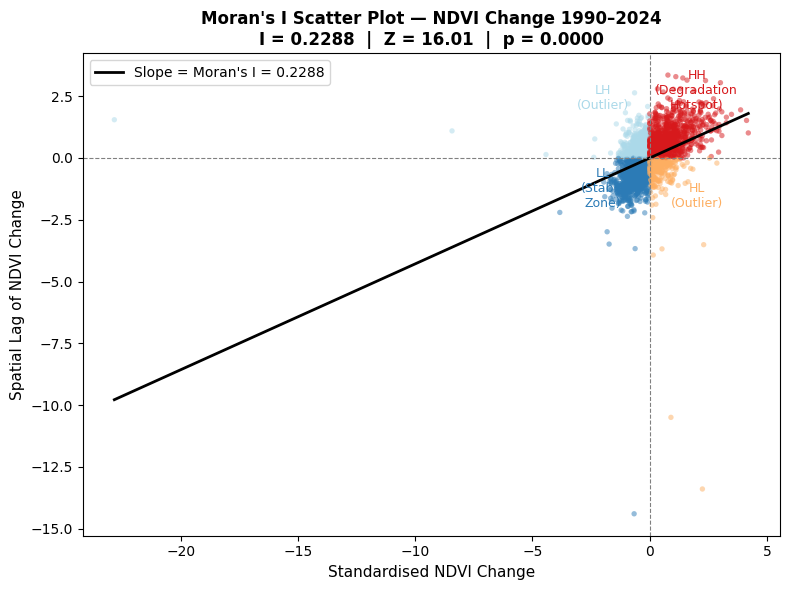


✅ Global Moran's I complete — scatter plot saved!


In [2]:
# ─────────────────────────────────────────────────────────────────────
# STEP 2 — Global Moran's I on NDVI Change
# ─────────────────────────────────────────────────────────────────────

# ── Sample NDVI change on a regular grid ─────────────────────────────
# We sample at 5km intervals — fine enough to capture spatial patterns
# but small enough to stay within GEE memory limits
SAMPLE_SCALE = 5000   # 5km grid spacing
GRID_SIZE    = 50     # approximate grid dimensions

print("⏳ Sampling NDVI change values on regular grid...")

samples = ndvi_change_total.sample(
    region=marsabit_geom,
    scale=SAMPLE_SCALE,
    numPixels=2500,
    seed=42,
    geometries=True
)

# Convert to pandas DataFrame
sample_list = samples.getInfo()['features']
print(f"   ✓ Sampled {len(sample_list)} grid points")

# Extract values and coordinates
records = []
for f in sample_list:
    coords = f['geometry']['coordinates']
    props  = f['properties']
    ndvi_val = list(props.values())[0] if props else None
    if ndvi_val is not None:
        records.append({
            'lon': coords[0],
            'lat': coords[1],
            'ndvi_change': ndvi_val
        })

df = pd.DataFrame(records)
print(f"   ✓ Valid points retained: {len(df)}")
print(f"   ✓ NDVI change range: {df['ndvi_change'].min():.4f} to {df['ndvi_change'].max():.4f}")
print(f"   ✓ Mean NDVI change: {df['ndvi_change'].mean():.4f}")

# ── Build Spatial Weights Matrix ──────────────────────────────────────
# We reshape samples into an approximate grid and use rook contiguity
# (each cell connected to its 4 direct neighbours)
print("\n⏳ Building spatial weights matrix...")

# Sort by lat then lon to create grid structure
df_sorted = df.sort_values(['lat', 'lon']).reset_index(drop=True)
n         = len(df_sorted)

# Determine grid dimensions
n_cols = int(np.ceil(np.sqrt(n * 1.5)))
n_rows = int(np.ceil(n / n_cols))

# Pad array to fill grid
ndvi_array = df_sorted['ndvi_change'].values
pad_size   = n_rows * n_cols - len(ndvi_array)
ndvi_padded = np.append(ndvi_array, np.full(pad_size, np.nan))
ndvi_grid   = ndvi_padded.reshape(n_rows, n_cols)

# Replace NaN with mean for weights matrix computation
ndvi_filled = np.where(np.isnan(ndvi_grid), np.nanmean(ndvi_grid), ndvi_grid)
ndvi_flat   = ndvi_filled.flatten()

# Build rook contiguity weights (4-neighbours)
w = lat2W(n_rows, n_cols, rook=True)
w.transform = 'r'   # Row-standardize
print(f"   ✓ Weights matrix: {n_rows} × {n_cols} grid")
print(f"   ✓ Total observations: {w.n}")

# ── Compute Global Moran's I ──────────────────────────────────────────
print("\n⏳ Computing Global Moran's I...")
moran = Moran(ndvi_flat, w)

print("\n" + "=" * 55)
print("   GLOBAL MORAN'S I RESULTS")
print("=" * 55)
print(f"\n   Moran's I value : {moran.I:.4f}")
print(f"   Expected I      : {moran.EI:.4f}  (random = 0)")
print(f"   Z-score         : {moran.z_norm:.4f}")
print(f"   p-value         : {moran.p_norm:.4f}")

# Interpretation
if moran.p_norm < 0.05:
    if moran.I > 0:
        clustering = "✅ SIGNIFICANT POSITIVE SPATIAL CLUSTERING"
        meaning    = "Degradation is NOT random — it clusters in specific areas"
    else:
        clustering = "✅ SIGNIFICANT SPATIAL DISPERSION"
        meaning    = "Degradation is dispersed — opposite values are neighbours"
else:
    clustering = "⚠️ NO SIGNIFICANT SPATIAL PATTERN (p > 0.05)"
    meaning    = "Cannot reject random spatial distribution"

print(f"\n   Result          : {clustering}")
print(f"   Meaning         : {meaning}")
print("=" * 55)

# ── Moran Scatter Plot ────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Compute spatial lag
lag_ndvi = libpysal.weights.lag_spatial(w, ndvi_flat)

# Standardize for plot
ndvi_std = (ndvi_flat - ndvi_flat.mean()) / ndvi_flat.std()
lag_std  = (lag_ndvi - lag_ndvi.mean()) / lag_ndvi.std()

# Quadrant colours
colors = []
for x, y in zip(ndvi_std, lag_std):
    if x > 0 and y > 0:
        colors.append('#d7191c')    # HH — red
    elif x < 0 and y < 0:
        colors.append('#2c7bb6')    # LL — blue
    elif x > 0 and y < 0:
        colors.append('#fdae61')    # HL — orange
    else:
        colors.append('#abd9e9')    # LH — light blue

ax.scatter(ndvi_std, lag_std, c=colors, alpha=0.5, s=15, edgecolors='none')

# Regression line
m, b    = np.polyfit(ndvi_std, lag_std, 1)
x_line  = np.linspace(ndvi_std.min(), ndvi_std.max(), 100)
ax.plot(x_line, m * x_line + b, 'k-', linewidth=2, label=f"Slope = Moran's I = {moran.I:.4f}")

# Reference lines
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# Quadrant labels
ax.text( 2.0,  2.0, 'HH\n(Degradation\nHotspot)',  fontsize=9, color='#d7191c',  ha='center')
ax.text(-2.0, -2.0, 'LL\n(Stable\nZone)',           fontsize=9, color='#2c7bb6',  ha='center')
ax.text( 2.0, -2.0, 'HL\n(Outlier)',                fontsize=9, color='#fdae61',  ha='center')
ax.text(-2.0,  2.0, 'LH\n(Outlier)',                fontsize=9, color='#abd9e9',  ha='center')

ax.set_xlabel("Standardised NDVI Change", fontsize=11)
ax.set_ylabel("Spatial Lag of NDVI Change", fontsize=11)
ax.set_title(
    f"Moran's I Scatter Plot — NDVI Change 1990–2024\n"
    f"I = {moran.I:.4f}  |  Z = {moran.z_norm:.2f}  |  p = {moran.p_norm:.4f}",
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('/content/moran_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Global Moran's I complete — scatter plot saved!")

## 🗺️ STEP 3 — Local Moran's I / LISA (Where are the Hotspots?)

**What we are doing:**
Global Moran's I told us WHETHER degradation is clustered.
Local Moran's I (LISA) tells us exactly WHERE — producing a map
with four distinct cluster types for every location.

**The four LISA cluster types:**
| Cluster Type | Colour | Meaning |
|-------------|--------|---------|
| High-High (HH) | Red | Degradation hotspot — surrounded by degraded neighbours |
| Low-Low (LL) | Blue | Stable zone — surrounded by stable/improving neighbours |
| High-Low (HL) | Orange | Degradation outlier — isolated degraded area |
| Low-High (LH) | Light Blue | Stable outlier — isolated stable area surrounded by degraded |
| Not Significant | Grey | No statistically significant spatial pattern |

**Why LISA is more useful than Global Moran's I for policy:**
Global Moran's I gives one number for the entire county.
LISA gives a value for every location — so we can say exactly:
"The degradation hotspots are concentrated around Laisamis water
points and the Chalbi Desert margins — not Mt. Marsabit forest."

This spatial precision directly informs:
- Where to prioritise grazing zone restrictions
- Where to focus restoration interventions
- Which wards need urgent environmental governance attention

**Statistical threshold:**
Only clusters with p < 0.05 are shown as significant.
All other locations are classified as "Not Significant" (grey).

⏳ Computing Local Moran's I (LISA)...
   ✓ LISA computed for 2501 locations
   ✓ Permutations: 999 (for robust p-values)

── LISA Cluster Summary ──────────────────────────────
   High-High (Degradation Hotspots) :  123 locations
   Low-Low   (Stable Zones)          :  176 locations
   High-Low  (Degradation Outliers)  :   15 locations
   Low-High  (Stable Outliers)       :   14 locations
   Not Significant                   : 2173 locations
   ─────────────────────────────────────────────────
   Total                             : 2501 locations
   Significance threshold            : p < 0.05


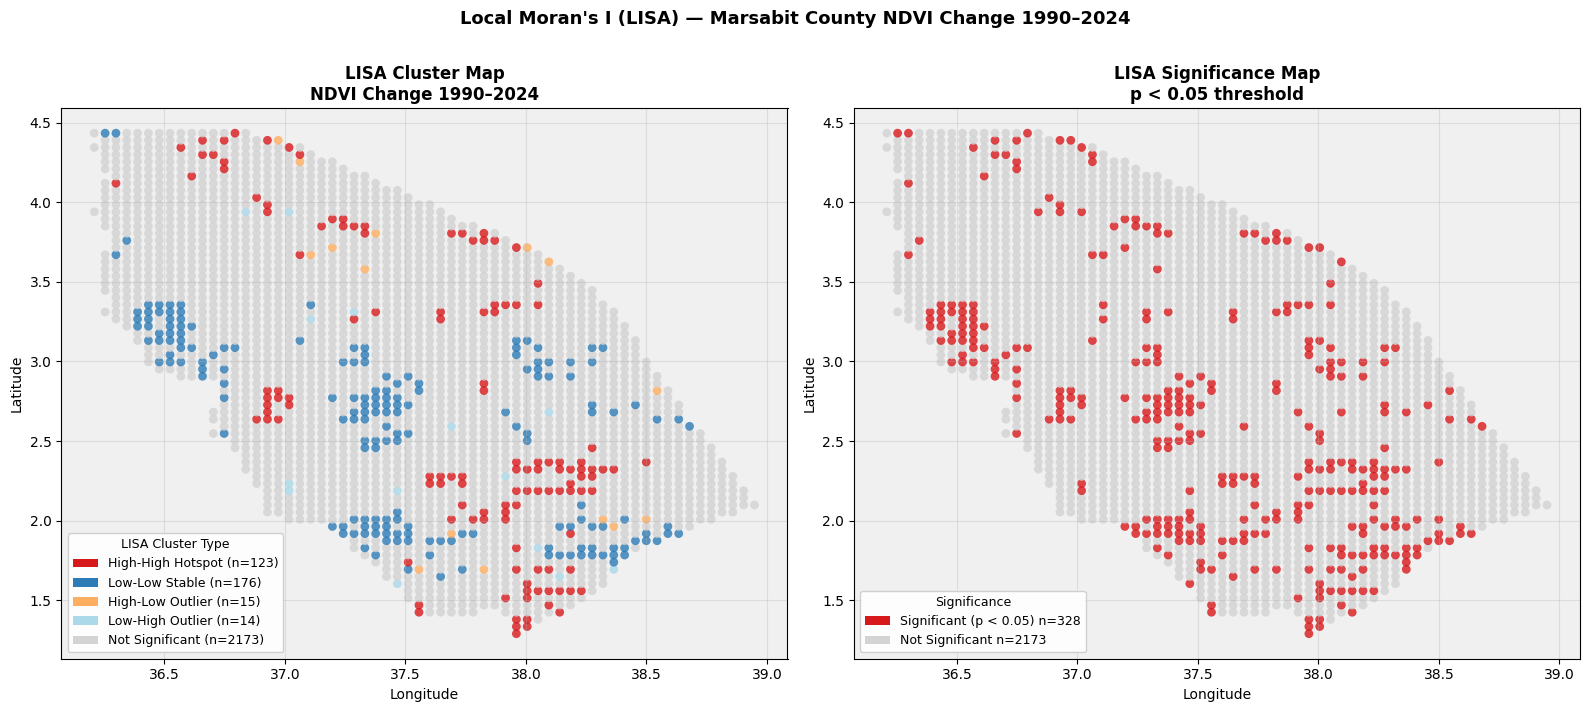


   LISA ANALYSIS COMPLETE

   Significant locations  : 328 / 2501
   HH hotspot coverage    : 4.9% of sampled area
   LL stable coverage     : 7.0% of sampled area

   📌 Policy Implication:
   Stable zones (176) exceed degradation hotspots (123)
   → Ecosystem broadly stable with localised degradation pressure

✅ LISA analysis complete — maps saved!


In [3]:
# ─────────────────────────────────────────────────────────────────────
# STEP 3 — Local Moran's I (LISA)
# Uses the same grid and weights matrix from Step 2
# ─────────────────────────────────────────────────────────────────────

print("⏳ Computing Local Moran's I (LISA)...")

# Compute LISA
lisa = Moran_Local(ndvi_flat, w, transformation='r', permutations=999, seed=42)

print(f"   ✓ LISA computed for {len(lisa.Is)} locations")
print(f"   ✓ Permutations: 999 (for robust p-values)")

# ── Classify into LISA quadrants ─────────────────────────────────────
# Quadrant codes from PySAL:
# 1 = HH (High-High)  → degradation hotspot
# 2 = LH (Low-High)   → stable outlier
# 3 = LL (Low-Low)    → stable zone
# 4 = HL (High-Low)   → degradation outlier

SIGNIFICANCE = 0.05
sig_mask = lisa.p_sim < SIGNIFICANCE

# Count cluster types
hh_count = np.sum((lisa.q == 1) & sig_mask)
ll_count = np.sum((lisa.q == 3) & sig_mask)
hl_count = np.sum((lisa.q == 4) & sig_mask)
lh_count = np.sum((lisa.q == 2) & sig_mask)
ns_count = np.sum(~sig_mask)

print(f"\n── LISA Cluster Summary ──────────────────────────────")
print(f"   High-High (Degradation Hotspots) : {hh_count:>4} locations")
print(f"   Low-Low   (Stable Zones)          : {ll_count:>4} locations")
print(f"   High-Low  (Degradation Outliers)  : {hl_count:>4} locations")
print(f"   Low-High  (Stable Outliers)       : {lh_count:>4} locations")
print(f"   Not Significant                   : {ns_count:>4} locations")
print(f"   ─────────────────────────────────────────────────")
print(f"   Total                             : {len(lisa.Is):>4} locations")
print(f"   Significance threshold            : p < {SIGNIFICANCE}")

# ── Build LISA colour array ───────────────────────────────────────────
lisa_colors = []
lisa_labels = []
for i in range(len(lisa.Is)):
    if not sig_mask[i]:
        lisa_colors.append('#d3d3d3')   # Not significant — grey
        lisa_labels.append('Not Significant')
    elif lisa.q[i] == 1:
        lisa_colors.append('#d7191c')   # HH — red
        lisa_labels.append('High-High (Hotspot)')
    elif lisa.q[i] == 3:
        lisa_colors.append('#2c7bb6')   # LL — blue
        lisa_labels.append('Low-Low (Stable)')
    elif lisa.q[i] == 4:
        lisa_colors.append('#fdae61')   # HL — orange
        lisa_labels.append('High-Low (Outlier)')
    elif lisa.q[i] == 2:
        lisa_colors.append('#abd9e9')   # LH — light blue
        lisa_labels.append('Low-High (Outlier)')
    else:
        lisa_colors.append('#d3d3d3')
        lisa_labels.append('Not Significant')

# ── Plot LISA Map ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── LEFT: LISA Cluster Map ────────────────────────────────────────────
ax1 = axes[0]
scatter = ax1.scatter(
    df_sorted['lon'][:len(lisa_colors)],
    df_sorted['lat'][:len(lisa_colors)],
    c=lisa_colors[:len(df_sorted)],
    s=40, alpha=0.8, edgecolors='none'
)

legend_elements = [
    Patch(facecolor='#d7191c', label=f'High-High Hotspot (n={hh_count})'),
    Patch(facecolor='#2c7bb6', label=f'Low-Low Stable (n={ll_count})'),
    Patch(facecolor='#fdae61', label=f'High-Low Outlier (n={hl_count})'),
    Patch(facecolor='#abd9e9', label=f'Low-High Outlier (n={lh_count})'),
    Patch(facecolor='#d3d3d3', label=f'Not Significant (n={ns_count})')
]

ax1.legend(handles=legend_elements, loc='lower left', fontsize=9,
           framealpha=0.9, title='LISA Cluster Type', title_fontsize=9)
ax1.set_xlabel('Longitude', fontsize=10)
ax1.set_ylabel('Latitude', fontsize=10)
ax1.set_title('LISA Cluster Map\nNDVI Change 1990–2024', fontsize=12, fontweight='bold')
ax1.set_facecolor('#f0f0f0')
ax1.grid(True, alpha=0.3)

# ── RIGHT: LISA Significance Map ─────────────────────────────────────
ax2 = axes[1]
sig_colors = ['#d7191c' if s else '#d3d3d3' for s in sig_mask]

ax2.scatter(
    df_sorted['lon'][:len(sig_colors)],
    df_sorted['lat'][:len(sig_colors)],
    c=sig_colors[:len(df_sorted)],
    s=40, alpha=0.8, edgecolors='none'
)

sig_legend = [
    Patch(facecolor='#d7191c', label=f'Significant (p < 0.05) n={np.sum(sig_mask)}'),
    Patch(facecolor='#d3d3d3', label=f'Not Significant n={ns_count}')
]
ax2.legend(handles=sig_legend, loc='lower left', fontsize=9,
           framealpha=0.9, title='Significance', title_fontsize=9)
ax2.set_xlabel('Longitude', fontsize=10)
ax2.set_ylabel('Latitude', fontsize=10)
ax2.set_title('LISA Significance Map\np < 0.05 threshold', fontsize=12, fontweight='bold')
ax2.set_facecolor('#f0f0f0')
ax2.grid(True, alpha=0.3)

plt.suptitle('Local Moran\'s I (LISA) — Marsabit County NDVI Change 1990–2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/lisa_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── LISA Statistics Summary ───────────────────────────────────────────
print("\n" + "=" * 55)
print("   LISA ANALYSIS COMPLETE")
print("=" * 55)
print(f"\n   Significant locations  : {np.sum(sig_mask)} / {len(lisa.Is)}")
print(f"   HH hotspot coverage    : {hh_count/len(lisa.Is)*100:.1f}% of sampled area")
print(f"   LL stable coverage     : {ll_count/len(lisa.Is)*100:.1f}% of sampled area")
print(f"\n   📌 Policy Implication:")
if hh_count > ll_count:
    print(f"   Degradation hotspots ({hh_count}) exceed stable zones ({ll_count})")
    print(f"   → Targeted intervention needed in HH cluster areas")
else:
    print(f"   Stable zones ({ll_count}) exceed degradation hotspots ({hh_count})")
    print(f"   → Ecosystem broadly stable with localised degradation pressure")
print("=" * 55)
print("\n✅ LISA analysis complete — maps saved!")